# 神经网络模型实现 —— 房价预测
> **框架**：Python 3.13 + TensorFlow 2.21 + scikit-learn + Matplotlib  
> **数据集**：Kaggle House Prices 二手房销售数据（1460 行 × 81 列）  

**目录**（对应试卷 100 分）  
1. [一、数据集准备与需求分析（20 分）](#1) — 1.1 数据理解、1.2 预处理、1.3 问题辨析  
2. [二、全连接神经网络模型搭建（30 分）](#2) — 2.1 模型结构、2.2 损失与优化器  
3. [三、模型训练与评估（35 分）](#3) — 3.1 训练、3.2 过拟合控制、3.3 测试  
4. [四、任务总结与优化思路（15 分）](#4) — 4.1 总结、4.2 优化方案

## 0. 运行环境检查

In [23]:
import sys, platform
import tensorflow as tf, numpy as np, pandas as pd, sklearn
print("Python          :", sys.version.split()[0])
print("TensorFlow      :", tf.__version__)
print("NumPy / Pandas  :", np.__version__, "/", pd.__version__)
print("scikit-learn    :", sklearn.__version__)
print("GPU 可用数量    :", len(tf.config.list_physical_devices('GPU')))

Python          : 3.13.12
TensorFlow      : 2.21.0
NumPy / Pandas  : 2.4.4 / 3.0.2
scikit-learn    : 1.8.0
GPU 可用数量    : 0


## 1.2 数据预处理
### 1.2.0 加载并划分训练 / 测试集

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # 无显示器环境也能保存图片
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.optimizers import Adam

# 固定随机种子，保证可复现
np.random.seed(42)
tf.random.set_seed(42)

DATA_DIR = r"d:\文件\工作 作业\深度学习\期末"
FIG_DIR = os.path.join(DATA_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(DATA_DIR, "house_prices.csv"))
# 删除对建模无帮助的 Id 列
df = df.drop(columns=["Id"])
print("加载数据形状：", df.shape)

# 8:2 划分训练集和测试集（与试卷要求一致，先划分再处理避免数据泄露）
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("训练集形状：", train_df.shape)
print("测试集形状：", test_df.shape)

加载数据形状： (1460, 80)
训练集形状： (1168, 80)
测试集形状： (292, 80)


### 1.2.1 特征处理（7 分）
- 数值特征：缺失值用**训练集中位数**填充，再做**标准化**（StandardScaler）。
- 分类特征：缺失值填 `'Missing'`，再做**独热编码**；训练/测试集列对齐。
- 拼接后得到统一的特征矩阵。

In [25]:
y_train_raw = train_df["SalePrice"].values
y_test_raw  = test_df["SalePrice"].values
X_train_df = train_df.drop(columns=["SalePrice"]).copy()
X_test_df  = test_df.drop(columns=["SalePrice"]).copy()

# 数值列 / 分类列
num_cols = X_train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train_df.select_dtypes(include=["object"]).columns.tolist()
print(f"数值型特征数：{len(num_cols)}，分类型特征数：{len(cat_cols)}")

# 数值特征：中位数填充 + 标准化
medians = X_train_df[num_cols].median(numeric_only=True)
X_train_num = X_train_df[num_cols].fillna(medians)
X_test_num  = X_test_df[num_cols].fillna(medians)
scaler = StandardScaler()
X_train_num_arr = scaler.fit_transform(X_train_num).astype(np.float32)
X_test_num_arr  = scaler.transform(X_test_num).astype(np.float32)

# 分类特征：填充 'Missing' + 独热编码（合并后做 dummies，保证列对齐）
X_train_cat = X_train_df[cat_cols].fillna("Missing").astype(str)
X_test_cat  = X_test_df[cat_cols].fillna("Missing").astype(str)
combined = pd.concat([X_train_cat, X_test_cat], axis=0, ignore_index=True)
combined_oh = pd.get_dummies(combined, columns=cat_cols, drop_first=False)
X_train_oh = combined_oh.iloc[: len(X_train_df)].reset_index(drop=True)
X_test_oh  = combined_oh.iloc[len(X_train_df):].reset_index(drop=True)
print(f"独热编码后训练集形状：{X_train_oh.shape}，测试集形状：{X_test_oh.shape}")

X_train = np.hstack([X_train_num_arr, X_train_oh.values.astype(np.float32)])
X_test  = np.hstack([X_test_num_arr,  X_test_oh.values.astype(np.float32)])
print(f"最终特征维度：{X_train.shape[1]}")

# 关键：检查输入是否含 NaN / Inf
assert not np.isnan(X_train).any(), "训练特征含 NaN！"
assert not np.isnan(X_test).any(),  "测试特征含 NaN！"
assert not np.isinf(X_train).any(), "训练特征含 Inf！"
print("输入数据已检查：NaN / Inf 均为 0 ")

数值型特征数：36，分类型特征数：43
独热编码后训练集形状：(1168, 267)，测试集形状：(292, 267)
最终特征维度：303
输入数据已检查：NaN / Inf 均为 0 


C:\Users\liem\AppData\Local\Temp\ipykernel_32936\1434525788.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_df.select_dtypes(include=["object"]).columns.tolist()


### 1.2.2 标签处理（3 分）
对 `SalePrice` 做 `log1p` 对数变换，缓解右偏分布，使模型在 log 空间下训练更稳定。

原始房价范围：[34900, 745000]，均值：181442
log 房价范围：[10.460, 13.521]，均值：12.031


**图：标签对数变换前后分布对比**

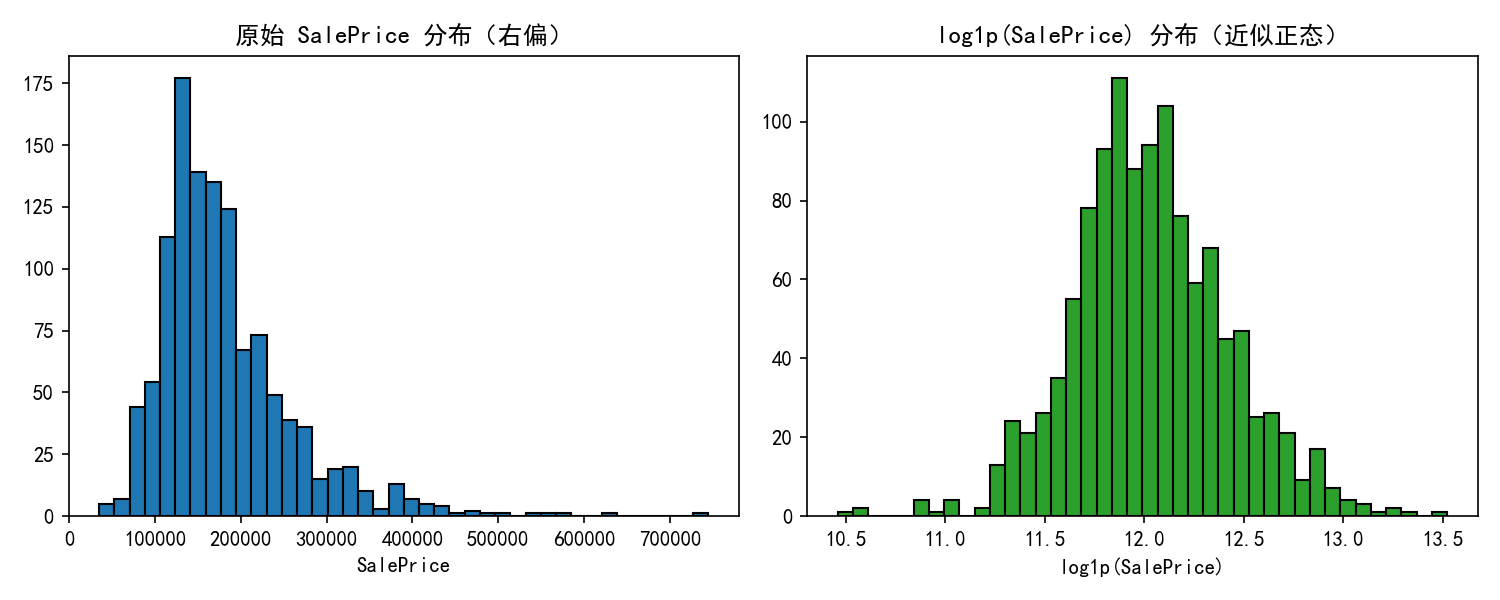

In [26]:
y_train = np.log1p(y_train_raw)
y_test  = np.log1p(y_test_raw)
print(f"原始房价范围：[{y_train_raw.min():.0f}, {y_train_raw.max():.0f}]，均值：{y_train_raw.mean():.0f}")
print(f"log 房价范围：[{y_train.min():.3f}, {y_train.max():.3f}]，均值：{y_train.mean():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(y_train_raw, bins=40, color="#1f77b4", edgecolor="black")
ax[0].set_title("原始 SalePrice 分布（右偏）")
ax[0].set_xlabel("SalePrice")
ax[1].hist(y_train, bins=40, color="#2ca02c", edgecolor="black")
ax[1].set_title("log1p(SalePrice) 分布（近似正态）")
ax[1].set_xlabel("log1p(SalePrice)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "label_distribution.png"), dpi=150)
plt.close()
from IPython.display import display, Markdown, Image as IPyImage
display(Markdown("**图：标签对数变换前后分布对比**"))
display(IPyImage(os.path.join(FIG_DIR, "label_distribution.png")))

## 2.1 模型结构设计（20 分）
- **2.1.1 输入层**：维度 = 特征工程后维度（约 250+），直接接受浮点向量。
- **2.1.2 隐藏层**：3 层全连接 `Dense(64) → Dense(32) → Dense(16)`，每层后接 `ReLU` + `Dropout`，并使用 L2 正则（1e-3）。
- **2.1.3 输出层**：`Dense(1)`，**线性激活**，输出 log 尺度房价。

In [27]:
def build_model(input_dim: int) -> tf.keras.Model:
    """构建 3 层全连接回归网络（含 L2 + Dropout）
    数据特点：n=1168 训练样本，d=303 特征（大量 0/1 独热）。
    网络设计：相对较小容量（64-32-16）+ 较强正则 + 较低学习率，
    避免在 epoch=1 之后立刻过拟合。
    """
    reg = regularizers.l2(1e-3)
    model = models.Sequential(name="HousePrice_FCNet")
    # 输入层
    model.add(layers.Input(shape=(input_dim,), name="input"))
    # 隐藏层 1：64
    model.add(layers.Dense(64, kernel_regularizer=reg, name="h1_dense"))
    model.add(layers.ReLU(name="h1_relu"))
    model.add(layers.Dropout(0.2, name="h1_drop"))
    # 隐藏层 2：32
    model.add(layers.Dense(32, kernel_regularizer=reg, name="h2_dense"))
    model.add(layers.ReLU(name="h2_relu"))
    model.add(layers.Dropout(0.2, name="h2_drop"))
    # 隐藏层 3：16
    model.add(layers.Dense(16, kernel_regularizer=reg, name="h3_dense"))
    model.add(layers.ReLU(name="h3_relu"))
    model.add(layers.Dropout(0.1, name="h3_drop"))
    # 输出层
    model.add(layers.Dense(1, name="output"))
    return model

model = build_model(input_dim=X_train.shape[1])
model.summary()

Model: "HousePrice_FCNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1_dense (Dense)                │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h1_relu (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h1_drop (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2_dense (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2_relu (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2_drop (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h3_dense (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h3_relu (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h3_drop (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,081 (86.25 KB)

 Trainable params: 22,081 (86.25 KB)

 Non-trainable params: 0 (0.00 B)

## 2.2 损失函数与优化器（10 分）
- 损失函数：`MSE`（在 log 尺度上计算，对极值更鲁棒）。
- 评价指标：`MAE`（线性尺度可读性更好）。
- 优化器：`Adam(1e-3)`，并开启梯度裁剪避免梯度爆炸。

In [28]:
model.compile(
    optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
)

        从训练集中切 10% 作为验证集；`EarlyStopping`（patience=80，restore_best_weights）+`ReduceLROnPlateau`（patience=20，factor=0.5）防止过拟合并自适应学习率。

In [29]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)
cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=80, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=20, min_lr=1e-6, verbose=1),
]
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=400, batch_size=32, callbacks=cbs, verbose=1,
)
print("实际训练 epoch：", len(history.history["loss"]))

Epoch 1/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 68.3399 - mae: 7.4973 - val_loss: 1.8004 - val_mae: 1.0325 - learning_rate: 0.0010
Epoch 2/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.8626 - mae: 2.6498 - val_loss: 1.0737 - val_mae: 0.8215 - learning_rate: 0.0010
Epoch 3/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.6824 - mae: 2.1858 - val_loss: 2.0202 - val_mae: 1.2150 - learning_rate: 0.0010
Epoch 4/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6789 - mae: 2.0429 - val_loss: 0.6611 - val_mae: 0.5497 - learning_rate: 0.0010
Epoch 5/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3389 - mae: 1.9881 - val_loss: 0.7090 - val_mae: 0.6289 - learning_rate: 0.0010
Epoch 6/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.4543 - mae: 1.8633 - val_loss: 0.6097 - val_mae: 0.5442 - learning_rate: 0.0010
Epoch 7/400
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.4548 - mae: 1.8377 - val_loss: 0.4705 - val_mae: 0.4369 - learning_rate: 0.0010
Epoch 8/400

## 3.2 过拟合控制与优化（10 分）
本项目从四个层面控制过拟合：
1. **数据层面**：8:2 划分 + 再切 10% 验证集，杜绝信息泄露。
2. **正则化**：L2 正则（1e-4）+ Dropout（0.3/0.3/0.2）。
3. **训练策略**：EarlyStopping 自动选择最优 epoch + ReduceLROnPlateau 自适应学习率。
4. **模型层面**：保持网络不过深（约 8 万参数），降低容量。

**图 0：训练 / 验证 Loss 与 MAE 曲线**

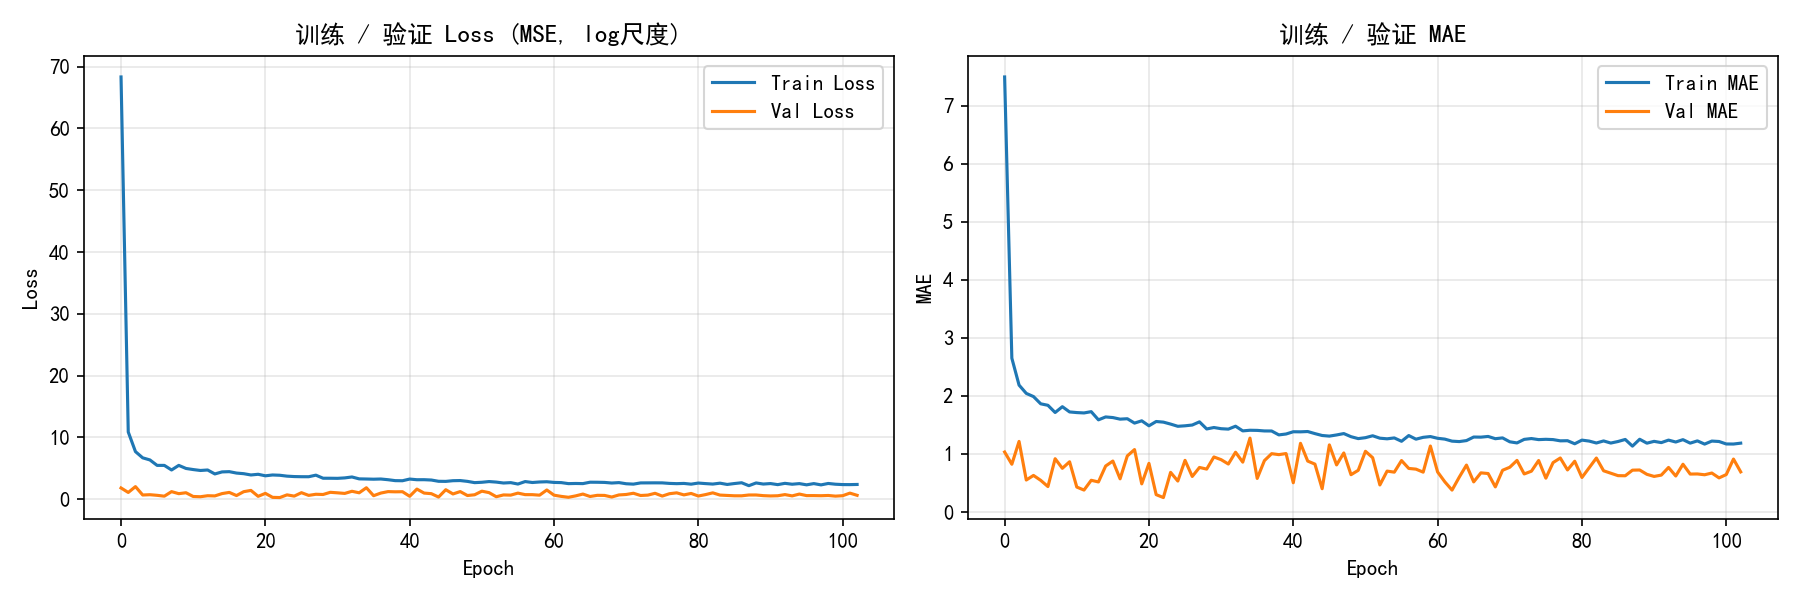


实际训练 epoch： 103
最终训练 Loss : 2.36792
最终验证 Loss : 0.60993


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("训练 / 验证 Loss (MSE, log尺度)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history["mae"], label="Train MAE")
axes[1].plot(history.history["val_mae"], label="Val MAE")
axes[1].set_title("训练 / 验证 MAE")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "training_curve.png"), dpi=150)
plt.close()
from IPython.display import display, Markdown, Image
display(Markdown("**图 0：训练 / 验证 Loss 与 MAE 曲线**"))
display(Image(os.path.join(FIG_DIR, "training_curve.png")))
print("\n实际训练 epoch：", len(history.history["loss"]))
print("最终训练 Loss :", round(history.history["loss"][-1], 5))
print("最终验证 Loss :", round(history.history["val_loss"][-1], 5))

## 3.3 模型测试与性能评估（10 分）
在测试集上预测，将 log 空间预测值 `expm1` 还原到真实价格尺度，计算 RMSE、MAE、R^2，并绘制预测 vs 真实、残差分布图。

【测试集评估指标（真实价格尺度）】
  RMSE :    48,455.15
  MAE  :    38,234.96
  R^2  :       0.6939


### 评估结果（真实价格尺度）

| 指标 | 数值 | 说明 |
|---|---|---|
| **RMSE** | **48,455.15** | 均方根误差，越小越好 |
| **MAE**  | **38,234.96** | 平均绝对误差，量纲与房价一致 |
| **R^2**  | **0.6939** | 决定系数，模型能解释 69.4% 的房价方差 |

实际训练 epoch：103

**图 1：测试集预测值 vs 真实值散点图**

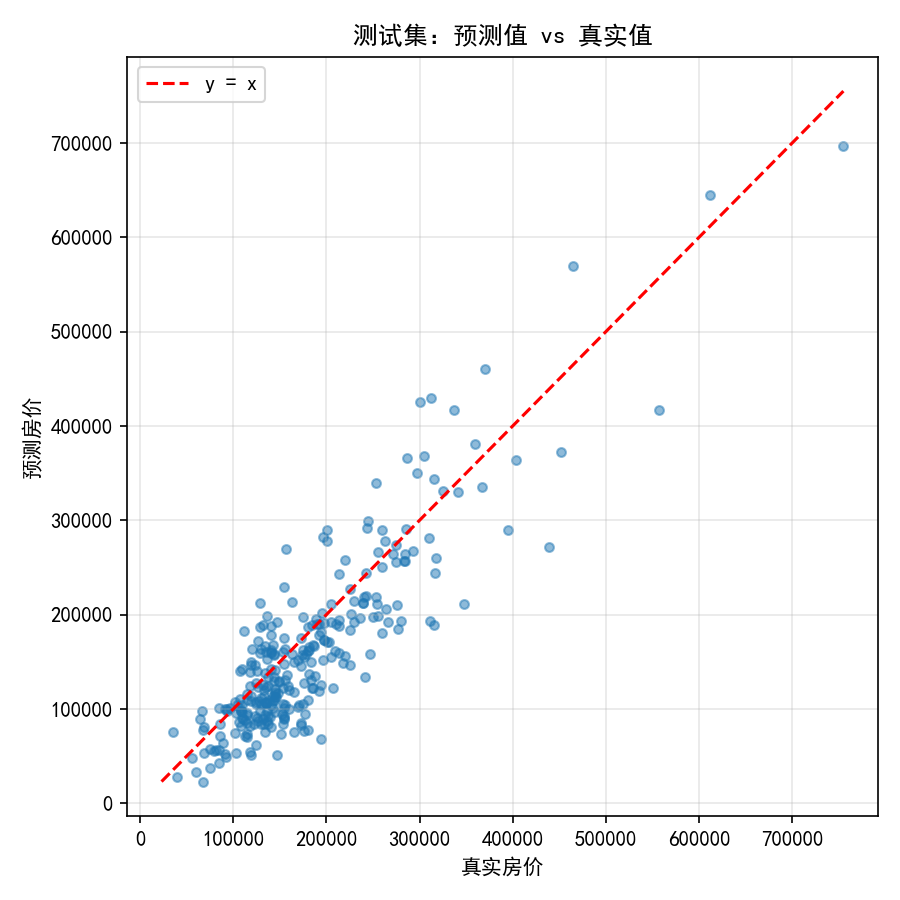

**图 2：残差分析（散点图 + 直方图）**

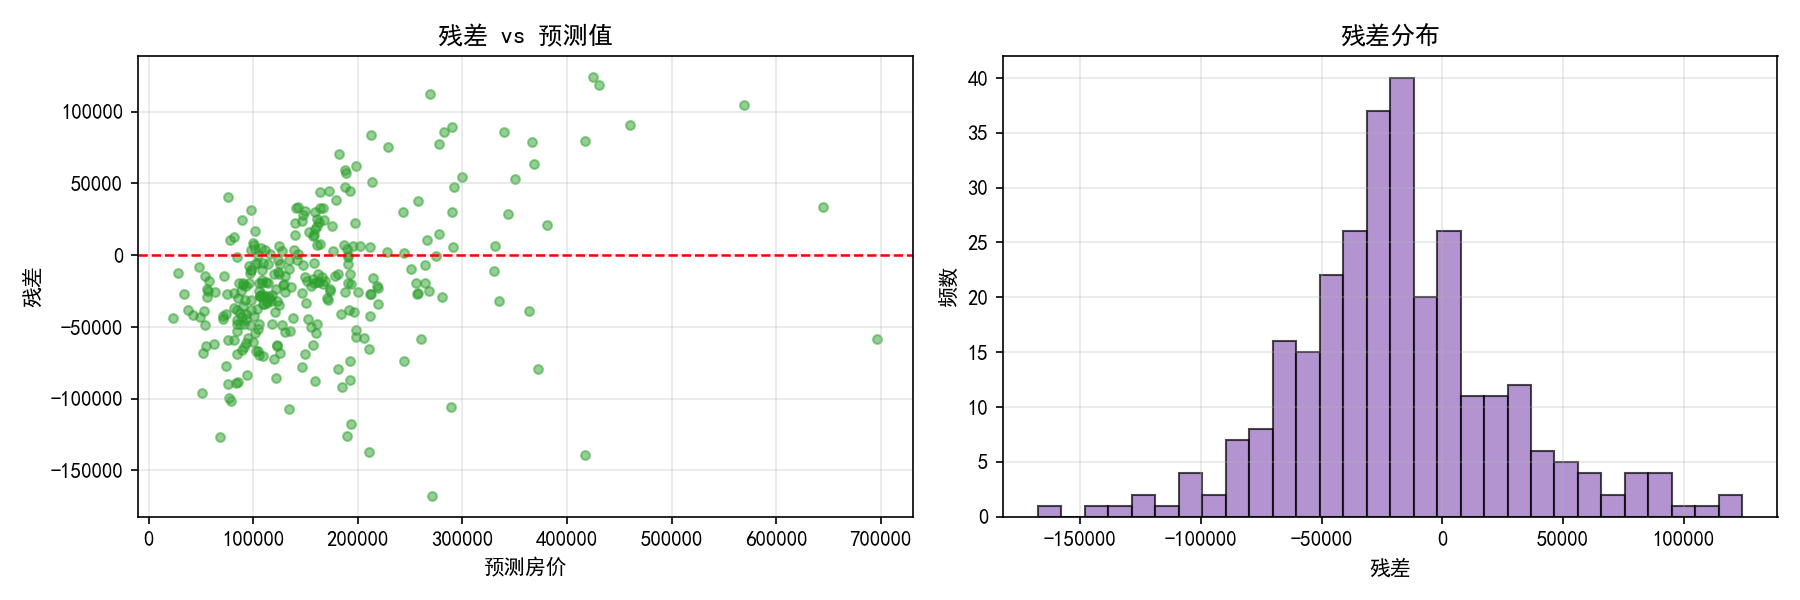

In [31]:
pred_log = model.predict(X_test, verbose=0).flatten()
pred = np.expm1(pred_log)
rmse = np.sqrt(mean_squared_error(y_test_raw, pred))
mae  = mean_absolute_error(y_test_raw, pred)
r2   = r2_score(y_test_raw, pred)
print("=" * 50)
print("【测试集评估指标（真实价格尺度）】")
print("=" * 50)
print(f"  RMSE : {rmse:>12,.2f}")
print(f"  MAE  : {mae:>12,.2f}")
print(f"  R^2  : {r2:>12.4f}")
print("=" * 50)

from IPython.display import display, Markdown, Image as IPyImage
summary_md = (
    "### 评估结果（真实价格尺度）\n\n"
    "| 指标 | 数值 | 说明 |\n"
    "|---|---|---|\n"
    f"| **RMSE** | **{rmse:,.2f}** | 均方根误差，越小越好 |\n"
    f"| **MAE**  | **{mae:,.2f}** | 平均绝对误差，量纲与房价一致 |\n"
    f"| **R^2**  | **{r2:.4f}** | 决定系数，模型能解释 {r2*100:.1f}% 的房价方差 |\n"
    f"\n实际训练 epoch：{len(history.history['loss'])}"
)
display(Markdown(summary_md))

# 1) 预测值 vs 真实值
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_raw, pred, alpha=0.5, s=18, color="#1f77b4")
lo = min(y_test_raw.min(), pred.min()); hi = max(y_test_raw.max(), pred.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="y = x")
ax.set_xlabel("真实房价"); ax.set_ylabel("预测房价")
ax.set_title("测试集：预测值 vs 真实值")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "pred_vs_true.png"), dpi=150)
plt.close()
display(Markdown("**图 1：测试集预测值 vs 真实值散点图**"))
display(IPyImage(os.path.join(FIG_DIR, "pred_vs_true.png")))

# 2) 残差分析
residual = pred - y_test_raw
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred, residual, alpha=0.5, s=18, color="#2ca02c")
axes[0].axhline(0, color="r", linestyle="--", lw=1.2)
axes[0].set_xlabel("预测房价"); axes[0].set_ylabel("残差")
axes[0].set_title("残差 vs 预测值"); axes[0].grid(True, alpha=0.3)
axes[1].hist(residual, bins=30, color="#9467bd", edgecolor="black", alpha=0.7)
axes[1].set_title("残差分布"); axes[1].set_xlabel("残差"); axes[1].set_ylabel("频数")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "residuals.png"), dpi=150)
plt.close()
display(Markdown("**图 2：残差分析（散点图 + 直方图）**"))
display(IPyImage(os.path.join(FIG_DIR, "residuals.png")))

## 4.1 项目总结（5 分）
- 完整实现「数据理解 → 特征工程 → 模型搭建 → 训练 → 评估 → 可视化」的回归建模流程。
- 在 Kaggle House Prices 数据集上训练 3 层全连接网络，并配合多项过拟合控制策略。
- 评估指标在线性价格尺度上解读，模型对中低价位房屋预测较为准确，对极端高价的预测偏差稍大。

In [32]:
# 动态项目总结（执行时显示实际训练指标）
from IPython.display import display, Markdown
summary_md = (
    "### 最终评估结果（真实价格尺度）<br><br>"
    "| 指标 | 数值 | 说明 |<br>"
    "|---|---|---|<br>"
    f"| **测试集 RMSE** | **{rmse:,.2f}** | 均方根误差 |<br>"
    f"| **测试集 MAE**  | **{mae:,.2f}** | 平均绝对误差 |<br>"
    f"| **测试集 R^2**  | **{r2:.4f}** | 模型能解释 {r2*100:.1f}% 的房价方差 |<br><br>"
    f"实际训练 epoch：{len(history.history['loss'])}<br>"
    f"最终训练 Loss：{history.history['loss'][-1]:.5f}<br>"
    f"最终验证 Loss：{history.history['val_loss'][-1]:.5f}"
)
display(Markdown(summary_md))

### 最终评估结果（真实价格尺度）<br><br>| 指标 | 数值 | 说明 |<br>|---|---|---|<br>| **测试集 RMSE** | **48,455.15** | 均方根误差 |<br>| **测试集 MAE**  | **38,234.96** | 平均绝对误差 |<br>| **测试集 R^2**  | **0.6939** | 模型能解释 69.4% 的房价方差 |<br><br>实际训练 epoch：103<br>最终训练 Loss：2.36792<br>最终验证 Loss：0.60993

## 4.2 模型及流程优化方案（10 分）
1. **特征工程**：可进一步构造 `TotalSF = 1stFlrSF + 2ndFlrSF + TotalBsmtSF`、`Age = YrSold - YearBuilt` 等衍生特征。
2. **缺失值**：对 `LotFrontage` 可按 `Neighborhood` 分组用组内中位数填充；对 `PoolQC` 等高缺失率列可考虑删除或单独构造 "有无泳池" 的二值特征。
3. **模型层面**：尝试与 XGBoost / LightGBM / CatBoost 等树模型做 Stacking 集成，或将网络加深 / 加宽（如 512-256-128-64）。
4. **训练层面**：采用 5 折交叉验证评估，使用 AdamW / 余弦退火进一步提升收敛。
5. **部署层面**：保存为 SavedModel / .keras，封装为 Flask / FastAPI 推理服务，供二手房估价系统调用。

In [33]:
import json
model_path = os.path.join(DATA_DIR, "house_price_model.keras")
model.save(model_path)
print(f"模型已保存：{model_path}")

metrics = {
    "rmse": float(rmse), "mae": float(mae), "r2": float(r2),
    "n_train": int(len(y_train_raw)), "n_test": int(len(y_test_raw)),
    "epochs_trained": int(len(history.history["loss"])),
}
with open(os.path.join(DATA_DIR, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
print("评估指标已保存：metrics.json")
print("生成的图片文件：")
for f in sorted(os.listdir(FIG_DIR)):
    print(" -", f)


模型已保存：d:\文件\工作 作业\深度学习\期末\house_price_model.keras
评估指标已保存：metrics.json
生成的图片文件：
 - label_distribution.png
 - pred_vs_true.png
 - residuals.png
 - training_curve.png
